In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors


import os
import scanpy as sc
import scvi
import seaborn as sns



/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

## Load Data

In [2]:
# Save dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris
atac_bc,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO


In [3]:
entropy_peaks_subdir = os.path.join(Union_cell_subdir, 'Entropy_cells_peaks')
entropy_peaks_gene_activity_file = os.path.join(entropy_peaks_subdir, 'DownstreamReanalysis', 'gene_activity_score.csv')
entropy_peaks_gene_activity = pd.read_csv(entropy_peaks_gene_activity_file, index_col=0).T

enough_frag_in_peaks_for_gene_activity = entropy_peaks_gene_activity.index.to_frame()
enough_frag_in_peaks_for_gene_activity['atac_bc'] = enough_frag_in_peaks_for_gene_activity.index.str.split('-').str[0]


In [4]:
enough_frag_in_peaks_for_gene_activity.shape

(2131, 2)

In [5]:
union_cell_info['enough_frag_in_peaks_for_gene_activity'] = union_cell_info.index.isin(enough_frag_in_peaks_for_gene_activity['atac_bc'])


union_cell_enough_info_BCs = union_cell_info.loc[(union_cell_info['enough_frag_in_peaks_for_gene_activity']) | (union_cell_info['rna_pass_CR']) ].copy()

In [6]:
union_cell_enough_info_BCs.groupby(['enough_frag_in_peaks_for_gene_activity', 'rna_pass_CR']).size().unstack(fill_value=0) # {BCs| good RNA} \in {BCs | enough_frag_in_peaks_for_gene_activity} 

rna_pass_CR,False,True
enough_frag_in_peaks_for_gene_activity,,
True,87,2044


In [7]:
union_cell_info.groupby(['enough_frag_in_peaks_for_gene_activity', 'leiden_RNA_scVI']).size().unstack(fill_value=0)

leiden_RNA_scVI,0,1,10,11,2,3,4,5,6,7,8,9,no_rna_info
enough_frag_in_peaks_for_gene_activity,,,,,,,,,,,,,
False,0,0,15,0,0,0,226,0,0,0,0,10,2
True,508,363,8,19,289,278,35,224,209,101,63,33,1


In [8]:
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
h5_rna_union_file = os.path.join(Union_cell_subdir, 'Union_3set_rna.h5ad')

h5_rna_union = sc.read_h5ad(h5_rna_union_file)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [9]:
h5_rna_union,

(AnnData object with n_obs × n_vars = 2381 × 36601
     obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'gene_ids', 'feature_types', 'genome',)

# Now only subset BCs that have either enough Frag in peaks for inferring gene-activity

In [10]:
h5_rna_enoughinfo = h5_rna_union[h5_rna_union.obs['atac_barcodes'].isin(enough_frag_in_peaks_for_gene_activity['atac_bc'])].copy()

h5_rna_enoughinfo, h5_rna_enoughinfo.shape # Still 1 BC does not have RNA-info

(AnnData object with n_obs × n_vars = 2130 × 36601
     obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'gene_ids', 'feature_types', 'genome',
 (2130, 36601))

In [11]:
sc.pp.filter_genes(h5_rna_enoughinfo, min_counts=3)
h5_rna_enoughinfo.raw = h5_rna_enoughinfo # keep full dimension safe
h5_rna_enoughinfo.layers['counts'] = h5_rna_enoughinfo.X
sc.pp.highly_variable_genes(
h5_rna_enoughinfo    ,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [12]:
SCVI_LATENT_KEY = "RNA_scVI_sufficientNfrag"
SCVI_CLUSTERS_KEY = "leiden_RNA_scVI_sufficientNfrag"


scvi.settings.seed = 0
scvi.model.SCVI.setup_anndata(h5_rna_enoughinfo, layer="counts")
vae = scvi.model.SCVI(h5_rna_enoughinfo, n_layers=3, n_latent=30, gene_likelihood="nb")
vae.train()

h5_rna_enoughinfo.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()

print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
vae_model_folder=os.path.join(entropy_dir, "_unionBCwsufficientNfrag_RNA_scvi_model")
vae.save(vae_model_folder, overwrite=True)

# clustering using scVI latent representation via Leiden
resolution = 0.5
sc.pp.neighbors(h5_rna_enoughinfo, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna_enoughinfo, min_dist=0.5)
sc.tl.leiden(h5_rna_enoughinfo, key_added=SCVI_CLUSTERS_KEY, resolution=resolution + 0.1 )

Seed set to 0
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 400/400: 100%|██████████| 400/400 [01:38<00:00,  4.06it/s, v_num=1, train_loss_step=5.48e+3, train_loss_epoch=5.38e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:38<00:00,  4.05it/s, v_num=1, train_loss_step=5.48e+3, train_loss_epoch=5.38e+3]
Save integrated samples into .h5ad file and trained SCVI model into subfolder



/tmp/ipykernel_805810/4286927686.py:20: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(h5_rna_enoughinfo, key_added=SCVI_CLUSTERS_KEY, resolution=resolution )


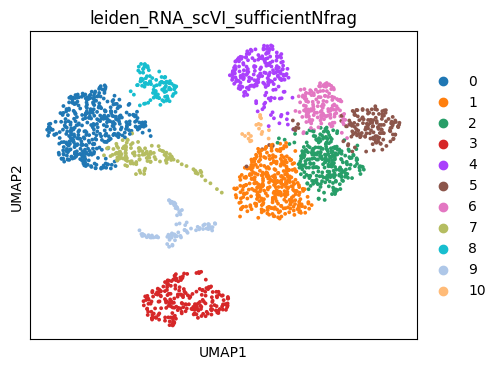

In [35]:

with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_enoughinfo, color=['leiden_RNA_scVI_sufficientNfrag'], wspace=0.2, size=30)


RNA_cluster_union_cell_sufficientNfrag_subset_file = os.path.join(Union_cell_subdir, 'Union_sufficientNfrag_BCs_RNA_cluster.tsv')
h5_rna_enoughinfo.obs.to_csv(RNA_cluster_union_cell_sufficientNfrag_subset_file, sep='\t')

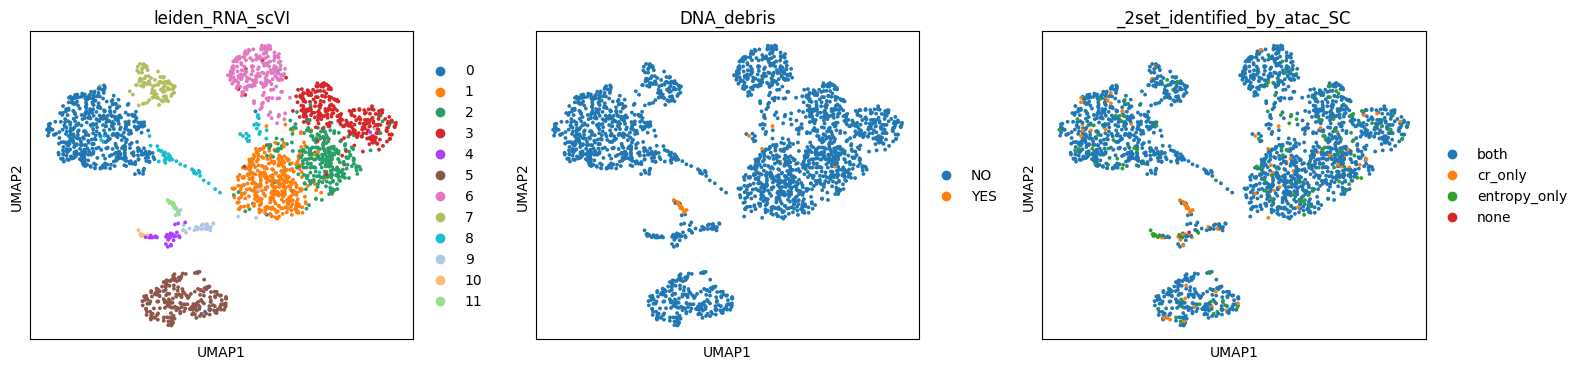

In [15]:
col_list = ['total_fragments', 	'atac_pass_CR', 	'atac_pass_entropy', 	'atac_pass_archr_TSS', 	'_2set_identified_by_atac_SC', 	'_2set_identified_by_atac_ST', 	'rna_barcodes', 	'rna_pass_CR', 	'Entropy', 	'leiden_RNA_scVI', 	'DNA_debris']
for col in col_list:
    h5_rna_enoughinfo.obs[col] = h5_rna_enoughinfo.obs['atac_barcodes'].map(union_cell_info[col])


with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_enoughinfo, color=['leiden_RNA_scVI', 
                                         'DNA_debris', '_2set_identified_by_atac_SC'], wspace=0.2, size=30, ncols=3, layer='log1p_cpm')

Text(0, 0.5, 'Total Fragments')

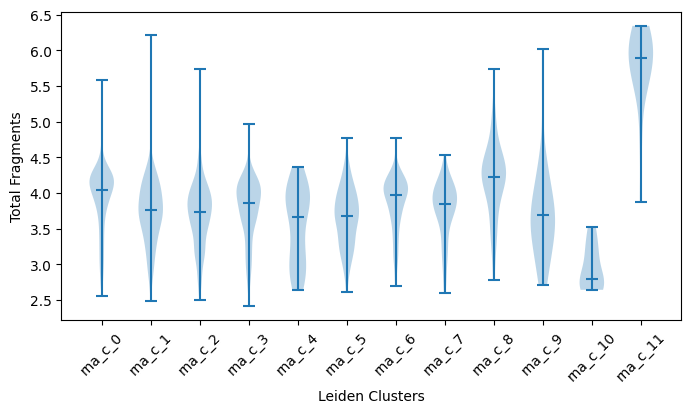

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

x_positions = h5_rna_enoughinfo.obs['leiden_RNA_scVI'].cat.codes.unique()
atac_read_depth = [h5_rna_enoughinfo.obs['total_fragments'].apply(lambda x: np.log10(x + 1)).loc[
    (h5_rna_enoughinfo.obs['leiden_RNA_scVI'].cat.codes == cluster) 
    ] for cluster in x_positions]
ax.violinplot(atac_read_depth, positions=x_positions, showmeans=False, showmedians=True)
ax.set_xticks(x_positions)
ax.set_xticklabels(['rna_c_' + str(i) for i in x_positions], rotation=45)
ax.set_xlabel('Leiden Clusters')
ax.set_ylabel('Total Fragments')

Text(0, 0.5, 'Entropy (log10)')

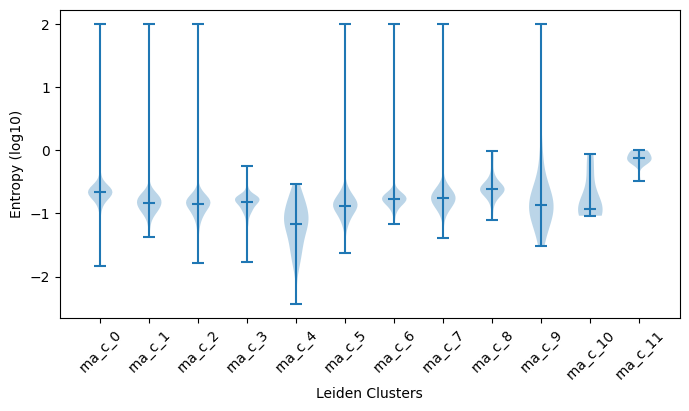

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

x_positions = h5_rna_enoughinfo.obs['leiden_RNA_scVI'].cat.codes.unique()
atac_read_depth = [h5_rna_enoughinfo.obs['Entropy'].fillna(100).apply(lambda x: np.log10(x)).loc[
    (h5_rna_enoughinfo.obs['leiden_RNA_scVI'].cat.codes == cluster) 
    ] for cluster in x_positions]
ax.violinplot(atac_read_depth, positions=x_positions, showmeans=False, showmedians=True)
ax.set_xticks(x_positions)
ax.set_xticklabels(['rna_c_' + str(i) for i in x_positions], rotation=45)
ax.set_xlabel('Leiden Clusters')
ax.set_ylabel('Entropy (log10)')

# Check ATAC for those union subset BCs that have sufficient frag-in-peaks for inferring gene-activity

In [18]:
entropy_peak_dir = os.path.join(Union_cell_subdir, "Entropy_cells_peaks")
atac_entropy_peak_pic = os.path.join(entropy_peak_dir, "DownstreamReanalysis", "bc_peak_pic_count.h5ad" )
h5_atac_entropy_peak = sc.read_h5ad(atac_entropy_peak_pic)
h5_atac_entropy_peak.obs['atac_barcodes'] = h5_atac_entropy_peak.obs['barcodes'].map(lambda x: x.split("-")[0])


In [19]:
h5_atac_enoughinfo = h5_atac_entropy_peak[h5_atac_entropy_peak.obs['atac_barcodes'].isin(union_cell_info.loc[union_cell_info['enough_frag_in_peaks_for_gene_activity'] == True].index)].copy()

In [20]:
h5_atac_enoughinfo

AnnData object with n_obs × n_vars = 2131 × 62565
    obs: 'barcodes', 'atac_barcodes'
    var: 'peak'

In [21]:

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

# %%
PEAKVI_LATENT_KEY = "X_peakvi_BC_sufficientNfrag"
PEAKVI_CLUSTERS_KEY = "clusters_peakvi_sufficientNfrag"

#%%
# # filter regions with less than 3% of the cells
print("# regions before filtering:", h5_atac_enoughinfo.shape[-1])

sc.pp.filter_genes(h5_atac_enoughinfo, min_cells=10)
print("# regions after filtering:", h5_atac_enoughinfo.shape[-1])

# Let's Use All the identified peaks for comarison (since entropy approach already has more peaks)
# train on h5_atac_entropy_peak_SADE
scvi.model.PEAKVI.setup_anndata(h5_atac_enoughinfo)
peak_model = scvi.model.PEAKVI(h5_atac_enoughinfo)
peak_model.train()
# #save model
des_model_dir = os.path.join(entropy_dir, "_unionBCwsufficientNfrag_PEAKVI_model")
peak_model.save(des_model_dir, overwrite=True)

# #save latent representation back adata
latent = peak_model.get_latent_representation()
h5_atac_enoughinfo.obsm[PEAKVI_LATENT_KEY] = latent
resolution = 0.5
sc.pp.neighbors(h5_atac_enoughinfo, use_rep=PEAKVI_LATENT_KEY)
sc.tl.umap(h5_atac_enoughinfo, min_dist=0.5)
sc.tl.leiden(h5_atac_enoughinfo, key_added=PEAKVI_CLUSTERS_KEY, resolution=resolution)

Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


Last run with scvi-tools version: 1.2.0
# regions before filtering: 62565
# regions after filtering: 61526


/tmp/ipykernel_805810/2623431589.py:19: DeprecationWarning: `save_best` is deprecated in v1.2 and will be removed in v1.3. Please use `enable_checkpointing` instead. See https://github.com/scverse/scvi-tools/issues/2568 for more details.
  peak_model.train()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers`

Epoch 226/500:  45%|████▌     | 226/500 [02:00<02:26,  1.87it/s, v_num=1, train_loss_step=1.68e+8, train_loss_epoch=1.75e+8]
Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 12979.662. Signaling Trainer to stop.


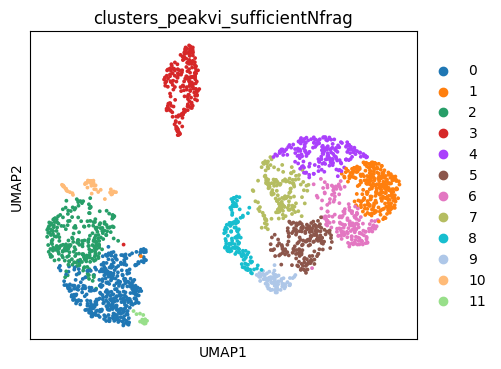

In [22]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_atac_enoughinfo, color=['clusters_peakvi_sufficientNfrag'], size=30)

In [23]:

col_list = ['total_fragments', 'atac_pass_CR', 'atac_pass_entropy',
       'atac_pass_archr_TSS', '_2set_identified_by_atac_SC',
       '_2set_identified_by_atac_ST', 'rna_barcodes', 'rna_pass_CR', 'Entropy', 'DNA_debris', 'leiden_RNA_scVI']
for col in col_list:
    h5_atac_enoughinfo.obs[col] = h5_atac_enoughinfo.obs['atac_barcodes'].map(union_cell_info[col])
    
h5_atac_enoughinfo.obs['log10_total_frag'] = np.log10(h5_atac_enoughinfo.obs['total_fragments'])

In [24]:
h5_atac_enoughinfo.obs.groupby(['clusters_peakvi_sufficientNfrag', 'leiden_RNA_scVI']).size().unstack(fill_value=0)

/tmp/ipykernel_805810/964596047.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_atac_enoughinfo.obs.groupby(['clusters_peakvi_sufficientNfrag', 'leiden_RNA_scVI']).size().unstack(fill_value=0)


leiden_RNA_scVI,0,1,10,11,2,3,4,5,6,7,8,9,no_rna_info
clusters_peakvi_sufficientNfrag,,,,,,,,,,,,,
0,275,0,3,1,1,0,6,0,1,94,26,2,1
1,0,208,1,0,54,1,4,1,1,2,0,4,0
2,231,0,0,2,0,0,1,0,0,4,29,1,0
3,1,0,0,0,0,0,5,208,0,0,1,0,0
4,0,133,0,0,46,0,0,5,0,1,1,1,0
5,0,0,2,0,10,155,1,1,5,0,0,6,0
6,0,9,1,0,153,6,0,0,0,0,0,3,0
7,0,8,0,0,23,109,1,1,5,0,3,1,0
8,0,0,0,0,0,2,0,1,123,0,0,1,0


In [25]:
h5_atac_enoughinfo.obs.groupby(['clusters_peakvi_sufficientNfrag', 'DNA_debris']).size().unstack(fill_value=0)

/tmp/ipykernel_805810/4126281385.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_atac_enoughinfo.obs.groupby(['clusters_peakvi_sufficientNfrag', 'DNA_debris']).size().unstack(fill_value=0)


DNA_debris,NO,YES
clusters_peakvi_sufficientNfrag,,
0,410,0
1,276,0
2,267,1
3,215,0
4,187,0
5,180,0
6,172,0
7,151,0
8,127,0


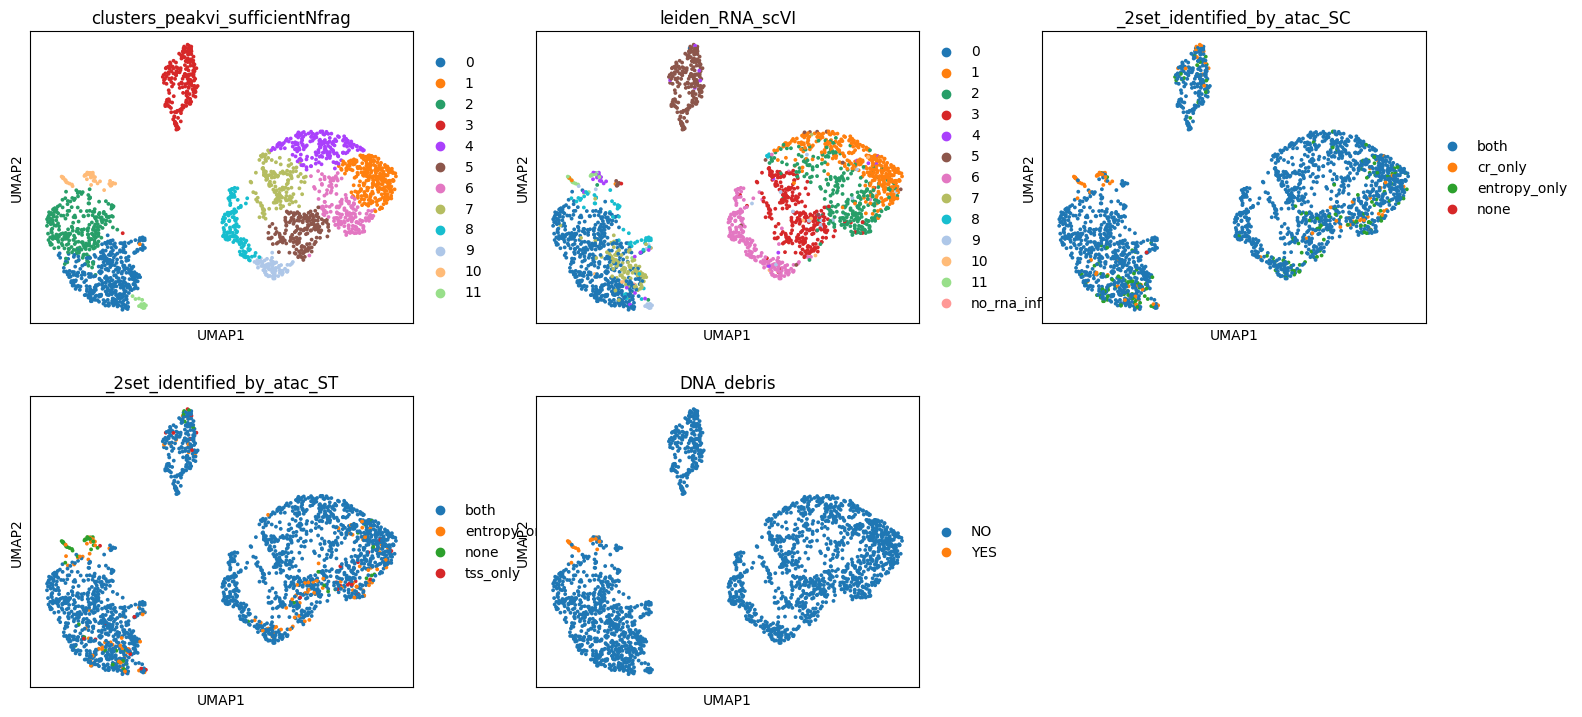

In [26]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_atac_enoughinfo, color=['clusters_peakvi_sufficientNfrag', 'leiden_RNA_scVI', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', 'DNA_debris'], wspace=0.2, size=30, ncols=3, )

### Cluster 10 on atac are dominant by DNA-debris barcodes, suggest this cluster are all low quality ATAC BCs

In [27]:
h5_atac_enoughinfo_no_c10 = h5_atac_enoughinfo[h5_atac_enoughinfo.obs['clusters_peakvi_sufficientNfrag'] != '10'].copy()


In [28]:
h5_atac_enoughinfo_no_c10.obs.groupby([ 'atac_pass_entropy']).size()

atac_pass_entropy
False      68
True     2016
dtype: int64

In [29]:
h5_atac_enoughinfo_no_c10.obs.groupby([ 'atac_pass_CR']).size()

atac_pass_CR
False     170
True     1914
dtype: int64

In [30]:
h5_atac_enoughinfo_no_c10.obs.groupby([ 'atac_pass_archr_TSS']).size()

atac_pass_archr_TSS
False     156
True     1928
dtype: int64

Text(0, 0.5, 'Total Fragments')

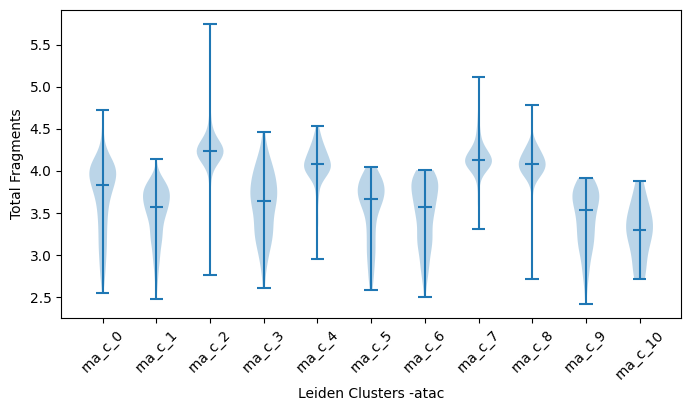

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

x_positions = h5_atac_enoughinfo_no_c10.obs['clusters_peakvi_sufficientNfrag'].cat.codes.unique()
atac_read_depth = [h5_atac_enoughinfo_no_c10.obs['total_fragments'].apply(lambda x: np.log10(x + 1)).loc[
    (h5_atac_enoughinfo_no_c10.obs['clusters_peakvi_sufficientNfrag'].cat.codes == cluster) 
    ] for cluster in x_positions]
ax.violinplot(atac_read_depth, positions=x_positions, showmeans=False, showmedians=True)
ax.set_xticks(x_positions)
ax.set_xticklabels(['rna_c_' + str(i) for i in x_positions], rotation=45)
ax.set_xlabel('Leiden Clusters -atac')
ax.set_ylabel('Total Fragments')

In [32]:

h5_atac_enoughinfo_no_c10.obs.groupby(['clusters_peakvi_sufficientNfrag', '_2set_identified_by_atac_SC']).size().unstack(fill_value=0)

/tmp/ipykernel_805810/1634686969.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_atac_enoughinfo_no_c10.obs.groupby(['clusters_peakvi_sufficientNfrag', '_2set_identified_by_atac_SC']).size().unstack(fill_value=0)


_2set_identified_by_atac_SC,both,cr_only,entropy_only,none
clusters_peakvi_sufficientNfrag,,,,
0,341,18,50,1
1,239,8,29,0
2,262,3,3,0
3,183,13,19,0
4,182,0,5,0
5,156,5,19,0
6,135,16,21,0
7,150,0,1,0
8,124,1,2,0


In [33]:
h5_atac_enoughinfo_no_c10.obs.groupby(['clusters_peakvi_sufficientNfrag', '_2set_identified_by_atac_ST']).size().unstack(fill_value=0)

/tmp/ipykernel_805810/85781224.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_atac_enoughinfo_no_c10.obs.groupby(['clusters_peakvi_sufficientNfrag', '_2set_identified_by_atac_ST']).size().unstack(fill_value=0)


_2set_identified_by_atac_ST,both,entropy_only,none,tss_only
clusters_peakvi_sufficientNfrag,,,,
0,364,27,13,6
1,244,24,4,4
2,255,10,2,1
3,192,10,5,8
4,186,1,0,0
5,156,19,4,1
6,140,16,5,11
7,150,1,0,0
8,125,1,1,0


In [34]:
h5_atac_enoughinfo_no_c10.obs.groupby(['clusters_peakvi_sufficientNfrag', 'DNA_debris']).size().unstack(fill_value=0)

/tmp/ipykernel_805810/3163038413.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_atac_enoughinfo_no_c10.obs.groupby(['clusters_peakvi_sufficientNfrag', 'DNA_debris']).size().unstack(fill_value=0)


DNA_debris,NO,YES
clusters_peakvi_sufficientNfrag,,
0,410,0
1,276,0
2,267,1
3,215,0
4,187,0
5,180,0
6,172,0
7,151,0
8,127,0
